In [1]:
!pip install -U torch torchvision opencv-python pycocotools
!pip install numpy==1.26.4



[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


Download COCO dataset For Training

In [ ]:
# !wget http://images.cocodataset.org/zips/val2017.zip
# !wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
# !unzip val2017.zip
# !unzip annotations_trainval2017.zip
# !rm val2014.zip
# !rm annotations_trainval2017.zip
# !unzip ./train2017.zip
# !unzip annotations_trainval2017.zip

In [1]:
import torch 
from torch import nn
from torch.nn.modules.conv import Conv2d
import torchvision.transforms as transform
from torchvision.transforms.transforms import Resize
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from PIL import Image as PILImage
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
class Conv_layer(nn.Module):
  def __init__(self,in_channels,out_channels):
    super(Conv_layer,self).__init__()
    self.model=nn.Sequential(
        nn.Conv2d(in_channels=in_channels,out_channels=out_channels,kernel_size=3,padding=1,bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        nn.Conv2d(in_channels=out_channels,out_channels=out_channels,kernel_size=3,padding=1,bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU()
    )

  def forward(self,x):
    return self.model(x)


In [4]:

class Unet(nn.Module):
  def __init__(self,in_channels=3,out_channels=1,features=[64,128,256,512]):
    super(Unet,self).__init__()
    self.down_model=nn.ModuleList()
    self.up_model=nn.ModuleList()
    self.pool=nn.MaxPool2d(kernel_size=2,stride=2)
    input_channel=in_channels
    for feature in features:
      self.down_model+=[
                        Conv_layer(input_channel,feature),
                        
      ]
      input_channel=feature
    for feature in reversed(features):
      input_channel=feature
      self.up_model+=[
                      nn.ConvTranspose2d(input_channel*2,feature,kernel_size=2,stride=2),
                      Conv_layer(input_channel*2,feature)
      ]
    
    self.bottle_neck=Conv_layer(features[-1],features[-1]*2)
    self.final_conv=nn.Conv2d(in_channels=features[0],out_channels=out_channels,kernel_size=1)
    self.Sigmoid_=nn.Sigmoid()

  def forward(self,x):
    skip_connections=[]
    for layer in self.down_model:
      x=layer(x)
      skip_connections.append(x)
      x=self.pool(x)
    x=self.bottle_neck(x)
    skip_connections=skip_connections[::-1]
    for idx in range(0,len(self.up_model),2):
      x=self.up_model[idx](x)
      skip_connection=skip_connections[idx//2]
      if x.shape!=skip_connection.shape:
        skip_connection=transform.functional.resize(skip_connection,size=x.shape[2:])
      concate=torch.concat((skip_connection,x),dim=1)
      x=self.up_model[idx+1](concate)

    return self.Sigmoid_(self.final_conv(x))


In [5]:
check_unet=Unet().to(device)

In [6]:
check_unet

Unet(
  (down_model): ModuleList(
    (0): Conv_layer(
      (model): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
      )
    )
    (1): Conv_layer(
      (model): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
      )
    )
    (2): Conv_layer(
 

In [8]:
dataDir='train2017'
dataType='train'
annFile="annotations/instances_train2017.json"

# Initialize the COCO api for instance annotations
coco=COCO(annFile)


loading annotations into memory...
Done (t=11.58s)
creating index...
index created!


In [12]:
catIDs = coco.getCatIds()
cats = coco.loadCats(catIDs)

print(cats)

[{'supercategory': 'person', 'id': 1, 'name': 'person'}, {'supercategory': 'vehicle', 'id': 2, 'name': 'bicycle'}, {'supercategory': 'vehicle', 'id': 3, 'name': 'car'}, {'supercategory': 'vehicle', 'id': 4, 'name': 'motorcycle'}, {'supercategory': 'vehicle', 'id': 5, 'name': 'airplane'}, {'supercategory': 'vehicle', 'id': 6, 'name': 'bus'}, {'supercategory': 'vehicle', 'id': 7, 'name': 'train'}, {'supercategory': 'vehicle', 'id': 8, 'name': 'truck'}, {'supercategory': 'vehicle', 'id': 9, 'name': 'boat'}, {'supercategory': 'outdoor', 'id': 10, 'name': 'traffic light'}, {'supercategory': 'outdoor', 'id': 11, 'name': 'fire hydrant'}, {'supercategory': 'outdoor', 'id': 13, 'name': 'stop sign'}, {'supercategory': 'outdoor', 'id': 14, 'name': 'parking meter'}, {'supercategory': 'outdoor', 'id': 15, 'name': 'bench'}, {'supercategory': 'animal', 'id': 16, 'name': 'bird'}, {'supercategory': 'animal', 'id': 17, 'name': 'cat'}, {'supercategory': 'animal', 'id': 18, 'name': 'dog'}, {'supercategory

In [12]:
filterClasses = ['person']

# Fetch class IDs only corresponding to the filterClasses
catIds = coco.getCatIds(catNms=filterClasses) 
# Get all images containing the above Category IDs
imgIds = coco.getImgIds(catIds=catIds)
# print(imgIds)
image_information =coco.loadImgs(imgIds[0])
# print(image_information)
file_name = os.path.join(dataDir, image_information[0]['file_name'])
Image = cv2.imread(file_name)
print(Image)
print(file_name)

NameError: name 'coco' is not defined

In [7]:
class CocoDataset(Dataset):
    def __init__(self, coco, imgIds,preprocess,preprocess_mask, filterClasses=['person'], root_dir='train2017/'):
        """
        Args:
            coco: COCO dataset object.
            imgIds: List of image IDs filtered by the class.
            filterClasses: List of categories to filter images.
            root_dir: Directory where COCO images are stored.
        """
        self.coco = coco
        self.imgIds = imgIds
        self.catIds = coco.getCatIds(catNms=filterClasses)
        self.root_dir = root_dir

        # Define the image transformations
        self.image_transform = preprocess

        self.mask_transform = preprocess_mask

    def __len__(self):
        return len(self.imgIds)

    def __getitem__(self, idx):
        image_info = self.coco.loadImgs(self.imgIds[idx])[0]
        file_name = f"{self.root_dir}{image_info['file_name']}"

        # Load image using OpenCV
        image = cv2.imread(file_name)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

        # Convert OpenCV NumPy image to PIL Image
        image = PILImage.fromarray(image)

        # Apply image transformations
        image = self.image_transform(image)

        # Load and process mask
        annIds = self.coco.getAnnIds(imgIds=image_info['id'], catIds=self.catIds, iscrowd=None)
        anns = self.coco.loadAnns(annIds)
        mask = np.zeros((image_info['height'], image_info['width']), dtype=np.uint8)

        for ann in anns:
            mask = np.maximum(self.coco.annToMask(ann), mask)
        
        # Convert mask to PIL Image before applying transform
        mask = PILImage.fromarray(mask)
        mask = self.mask_transform(mask)

        return image, mask



In [8]:
class BCELogDiceLoss(nn.Module):
    def __init__(self, alpha=1.0,beta=1.0, eps=1e-6):

        super(BCELogDiceLoss, self).__init__()
        self.alpha = alpha
        self.beta=beta
        self.eps = eps
        self.bce = nn.BCEWithLogitsLoss()  

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = logits
        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)
        
        intersection = (probs_flat * targets_flat).sum(dim=1)
        union = probs_flat.sum(dim=1) + targets_flat.sum(dim=1)
        
        dice_score = (2.0 * intersection + self.eps) / (union + self.eps)
        
        log_dice = -torch.log(dice_score/self.alpha)
        log_dice_loss = log_dice.mean()
        combined_loss = self.beta*bce_loss + self.alpha*log_dice_loss
        
        return combined_loss


In [9]:
preprocess=transform.Compose([
                              transform.ToTensor(),
                              transform.Resize((240,240)),
                              transform.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
preprocess_mask=transform.Compose([
                              transform.ToTensor(),
                              transform.Resize((240,240))
])

In [19]:
num_epochs=10
lr=0.0001
batch_size=10

In [ ]:

coco_dataset = CocoDataset(coco, imgIds,preprocess,preprocess_mask)
data_loader = DataLoader(coco_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
optimizer=torch.optim.Adam(check_unet.parameters(),lr=lr)
criterion = BCELogDiceLoss(alpha=10.0,beta=5)

In [1]:

# Training Loop
for epoch in range(num_epochs):
    check_unet.train()
    total_loss = 0.0
    dice_total = 0.0

    for idx, (image, labels) in enumerate(data_loader):
        image = image.to(device)
        labels = labels.float().to(device)

        # Forward pass
        output = check_unet(image)  # Logits output
        loss = criterion(output, labels)  # Dice Loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Compute Dice Score
        pred_mask =output# Convert logits to probabilities
        dice_score = (2 * (pred_mask * labels).sum(dim=(1, 2, 3))) / (
            (pred_mask + labels).sum(dim=(1, 2, 3)) + 1e-8
        )
        dice_total += dice_score.mean().item()

        # Logging every 50 batches
        if (idx + 1) % 50 == 0:
            print(f"Epoch {epoch+1}, Iteration {idx+1}, Loss: {loss.item():.4f}, Dice Score: {dice_score.mean().item():.4f}")

    # Epoch summary
    print(f"Epoch {epoch+1} Completed. Avg Loss: {total_loss/len(data_loader):.4f}, Avg Dice Score: {dice_total/len(data_loader):.4f}")

# Save trained model
torch.save(check_unet.state_dict(), "unet_trained.pth")
print("Model saved successfully!")


NameError: name 'num_epochs' is not defined

In [ ]:
check_unet.load_state_dict(torch.load("unet_trained.pth", map_location=device))
check_unet.to(device)

Validating Trained model in Unet

In [24]:
dataDir='/home/peshal/programming/Deep Learning/val2017'
dataType='val'
annFile="/home/peshal/programming/Deep Learning/annotations/instances_val2017.json"

coco=COCO(annFile)

loading annotations into memory...
Done (t=0.49s)
creating index...
index created!


/tmp/ipykernel_63112/2236047555.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  check_unet.load_state_dict(torch.load("./saved_model/unet_trained.pth", map_location=devi

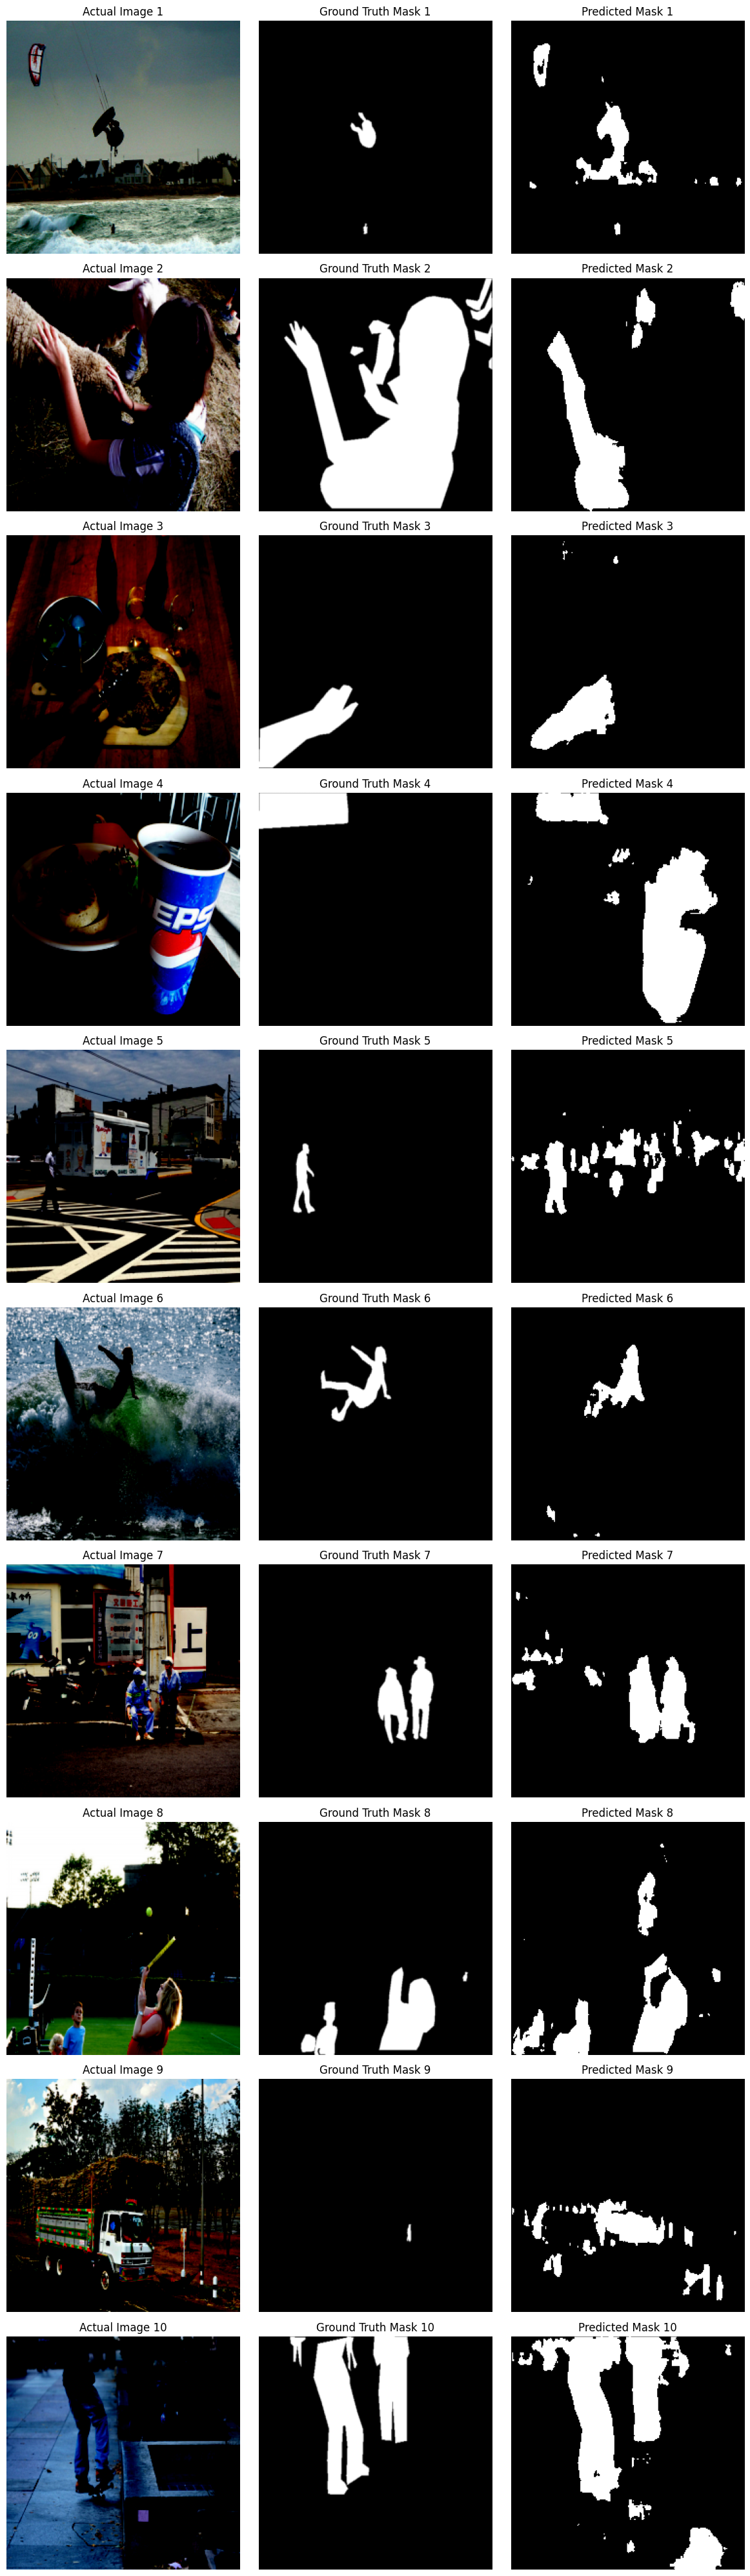

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
check_unet.load_state_dict(torch.load("./saved_model/unet_trained.pth", map_location=device))
check_unet.to(device)
check_unet.eval()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((240, 240)),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

filterClasses = ['person']
catIds = coco.getCatIds(catNms=filterClasses)
imgIds = coco.getImgIds(catIds=catIds)

batch_size = 1 
val_dataset = CocoDataset(coco, imgIds,preprocess,preprocess_mask ,filterClasses=['person'], root_dir=dataDir+"/")  
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

num_samples = 10
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

for idx, (image, mask) in enumerate(val_loader):
    if idx >= num_samples:
        break  
    image = image.to(device)
    mask = mask.to(device)

    with torch.no_grad():
        output = check_unet(image)
        pred_mask = output
    image_np = image.squeeze().cpu().numpy().transpose(1, 2, 0)  
    true_mask = mask.squeeze().cpu().numpy() * 255  
    pred_mask = (pred_mask.squeeze().cpu().numpy() > 0.7).astype(np.uint8) * 255 

    axes[idx, 0].imshow(image_np)
    axes[idx, 0].set_title(f"Actual Image {idx+1}")
    axes[idx, 0].axis("off")
    axes[idx, 1].imshow(true_mask, cmap="gray")
    axes[idx, 1].set_title(f"Ground Truth Mask {idx+1}")
    axes[idx, 1].axis("off")
    axes[idx, 2].imshow(pred_mask, cmap="gray")
    axes[idx, 2].set_title(f"Predicted Mask {idx+1}")
    axes[idx, 2].axis("off")

plt.tight_layout()
plt.show()
